In [1]:
!pip install tensorflow scikit-learn pandas numpy matplotlib seaborn scipy -q

import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize, linear_sum_assignment

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks, Input

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

OUTDIR = 'outputs'
os.makedirs(OUTDIR, exist_ok=True)

print('✅ All imports successful')
print(f'TensorFlow: {tf.__version__}')

✅ All imports successful
TensorFlow: 2.20.0


In [2]:

from google.colab import files
print('Upload your 3 CSV files...')
uploaded = files.upload()

def load_and_merge():
    print('Loading and merging 3 CSV files...')
    act  = pd.read_csv('activity_environment_data.csv')
    dig  = pd.read_csv('digital_interaction_data.csv')
    hlth = pd.read_csv('personal_health_data.csv')

    for df in [act, dig, hlth]:
        df.columns = [c.strip().lower() for c in df.columns]

    df = pd.merge(act, dig,  on=['user_id', 'timestamp'], how='inner')
    df = pd.merge(df,  hlth, on=['user_id', 'timestamp'], how='inner')

    print(f'  Merged shape : {df.shape}')
    print(f'  Anomaly dist : {df["anomaly_flag"].value_counts().to_dict()}')
    return df

df_raw = load_and_merge()

Upload your 3 CSV files...


Saving activity_environment_data.csv to activity_environment_data.csv
Saving digital_interaction_data.csv to digital_interaction_data.csv
Saving personal_health_data.csv to personal_health_data.csv
Loading and merging 3 CSV files...
  Merged shape : (10000, 40)
  Anomaly dist : {1: 6228, 0: 3772}


In [3]:

STRESS_MAP = {'Low': 0, 'Medium': 1, 'High': 2}
MOOD_MAP   = {'Happy': 0, 'Neutral': 1, 'Sad': 2,
              'Anxious': 3, 'Stressed': 4}
ECG_MAP    = {'Normal': 0, 'Abnormal': 1, 'Borderline': 0.5}

PHYSICAL_FEATURES = [
    'heart_rate', 'blood_oxygen_level', 'skin_temperature',
    'sleep_duration', 'deep_sleep_duration', 'rem_sleep_duration',
    'wakeups', 'body_fat_percentage', 'muscle_mass', 'bmi',
    'calories_intake', 'water_intake', 'health_score',
    'ecg_num', 'stress_num', 'snoring_num', 'age_risk',
    'cardio_index', 'sleep_index', 'health_dev',
]

BEHAVIOURAL_FEATURES = [
    'steps', 'calories_burned', 'distance_covered', 'exercise_duration',
    'ambient_temperature', 'altitude', 'uv_exposure',
    'screen_time', 'notifications_received',
    'mood_num', 'smoker_num', 'medication_num', 'alcohol_num',
    'lifestyle_risk', 'digital_stress', 'activity_deficit',
]

def engineer_features(df):
    df = df.copy()
    df['stress_num']     = df['stress_level'].map(STRESS_MAP).fillna(1)
    df['mood_num']       = df['mood'].map(MOOD_MAP).fillna(1)
    df['ecg_num']        = df['ecg'].map(ECG_MAP).fillna(0)
    df['smoker_num']     = (df['smoker'].str.lower() == 'yes').astype(int)
    df['medication_num'] = (df['medication'].str.lower() != 'none').astype(int)
    df['snoring_num']    = (df['snoring'].str.lower() == 'yes').astype(int)
    df['alcohol_num']    = df.get('alcohol_consumption',
        pd.Series(['None']*len(df))).map(
        {'None': 0, 'Low': 1, 'Moderate': 2, 'Heavy': 3}).fillna(0)

    if 'weight' in df.columns and 'height' in df.columns:
        df['bmi'] = df['weight'] / ((df['height'] / 100) ** 2 + 1e-9)
    else:
        df['bmi'] = 22.0

    if 'age' in df.columns:
        df['age_risk'] = pd.cut(df['age'],
            bins=[0, 30, 45, 60, 200],
            labels=[0, 1, 2, 3]).astype(float).fillna(0)
    else:
        df['age_risk'] = 0

    hr_z   = (df['heart_rate'] - df['heart_rate'].mean()) / \
             (df['heart_rate'].std() + 1e-9)
    spo2_z = -(df['blood_oxygen_level'] - df['blood_oxygen_level'].mean()) / \
              (df['blood_oxygen_level'].std() + 1e-9)

    df['cardio_index']     = hr_z + spo2_z + df['stress_num'] + df['ecg_num'] * 2
    df['sleep_index']      = (df['wakeups'] * 2 + df['snoring_num']
                              - df['deep_sleep_duration'].fillna(0)
                              - df['rem_sleep_duration'].fillna(0))
    df['lifestyle_risk']   = ((1 - df['steps'] / (df['steps'].max() + 1)) * 3
                              + df['smoker_num'] * 2 + df['alcohol_num']
                              + df['body_fat_percentage'] /
                              (df['body_fat_percentage'].max() + 1))
    df['digital_stress']   = (df['screen_time'] / (df['screen_time'].max() + 1)
                              + df['notifications_received'] /
                              (df['notifications_received'].max() + 1)
                              + df['stress_num'] / 2 + df['mood_num'] / 4)
    df['health_dev']       = 1.0 - df['health_score'] / \
                             (df['health_score'].max() + 1)
    df['activity_deficit'] = (-(df['steps'] / (df['steps'].max() + 1))
                               - df['calories_burned'] /
                               (df['calories_burned'].max() + 1))
    return df

def preprocess(df):
    print('Preprocessing...')
    df = engineer_features(df)
    y  = df['anomaly_flag'].values.astype(int)

    phys_avail = [c for c in PHYSICAL_FEATURES    if c in df.columns]
    beh_avail  = [c for c in BEHAVIOURAL_FEATURES if c in df.columns]
    all_feats  = phys_avail + beh_avail

    X_all  = df[all_feats].fillna(df[all_feats].median(numeric_only=True))
    X_phys = df[phys_avail].fillna(df[phys_avail].median(numeric_only=True))
    X_beh  = df[beh_avail].fillna(df[beh_avail].median(numeric_only=True))

    std_scaler = StandardScaler()
    X_std      = std_scaler.fit_transform(X_all)

    mm_phys   = MinMaxScaler()
    mm_beh    = MinMaxScaler()
    X_phys_mm = mm_phys.fit_transform(X_phys)
    X_beh_mm  = mm_beh.fit_transform(X_beh)

    print(f'  Physical features  : {len(phys_avail)}')
    print(f'  Behaviour features : {len(beh_avail)}')
    print(f'  Total features     : {len(all_feats)}')
    print(f'  Normal   : {(y==0).sum()}  Anomaly : {(y==1).sum()}')

    return (X_std, X_phys_mm, X_beh_mm, y,
            all_feats, phys_avail, beh_avail,
            std_scaler, mm_phys, mm_beh, df)

(X_std, X_phys_mm, X_beh_mm, y,
 all_feats, phys_feats, beh_feats,
 std_scaler, mm_phys, mm_beh, df_eng) = preprocess(df_raw)

print('\n✅ Feature engineering complete')

Preprocessing...
  Physical features  : 20
  Behaviour features : 16
  Total features     : 36
  Normal   : 3772  Anomaly : 6228

✅ Feature engineering complete


In [4]:

(
    X_std_tr,  X_std_te,
    X_phys_tr, X_phys_te,
    X_beh_tr,  X_beh_te,
    y_tr,      y_te
) = train_test_split(
    X_std, X_phys_mm, X_beh_mm, y,
    test_size=0.25, random_state=SEED, stratify=y
)

X_std_norm  = X_std_tr[y_tr == 0]
X_phys_norm = X_phys_tr[y_tr == 0]
X_beh_norm  = X_beh_tr[y_tr == 0]

X_phys_norm_tr, X_phys_norm_val = train_test_split(
    X_phys_norm, test_size=0.15, random_state=SEED)
X_beh_norm_tr,  X_beh_norm_val  = train_test_split(
    X_beh_norm,  test_size=0.15, random_state=SEED)


_, df_te_raw = train_test_split(
    df_eng, test_size=0.25, random_state=SEED,
    stratify=df_eng['anomaly_flag'])

print(f'Train : {len(X_std_tr)} '
      f'(normal={(y_tr==0).sum()}, anomaly={(y_tr==1).sum()})')
print(f'Test  : {len(X_std_te)} '
      f'(normal={(y_te==0).sum()}, anomaly={(y_te==1).sum()})')
print(f'AE train (normal only) : {len(X_phys_norm_tr)}')
print('✅ Split complete')

Train : 7500 (normal=2829, anomaly=4671)
Test  : 2500 (normal=943, anomaly=1557)
AE train (normal only) : 2404
✅ Split complete


In [5]:

def build_multimodal_autoencoder(n_phys, n_beh):
    # Physical stream encoder
    phys_input = Input(shape=(n_phys,), name='physical_input')
    px = layers.Dense(64, activation='relu', name='phys_enc1')(phys_input)
    px = layers.BatchNormalization(name='phys_bn1')(px)
    px = layers.Dropout(0.1, name='phys_drop1')(px)
    px = layers.Dense(32, activation='relu', name='phys_enc2')(px)
    phys_latent = layers.Dense(16, activation='relu',
                               name='phys_latent')(px)

    # Behavioural stream encoder
    beh_input = Input(shape=(n_beh,), name='behavioural_input')
    bx = layers.Dense(64, activation='relu', name='beh_enc1')(beh_input)
    bx = layers.BatchNormalization(name='beh_bn1')(bx)
    bx = layers.Dropout(0.1, name='beh_drop1')(bx)
    bx = layers.Dense(32, activation='relu', name='beh_enc2')(bx)
    beh_latent = layers.Dense(16, activation='relu',
                              name='beh_latent')(bx)

    # Fusion — concatenate both latent spaces
    fused = layers.Concatenate(name='fused_latent')(
        [phys_latent, beh_latent])

    # Shared decoder
    dx = layers.Dense(64,  activation='relu', name='dec1')(fused)
    dx = layers.BatchNormalization(name='dec_bn1')(dx)
    dx = layers.Dense(128, activation='relu', name='dec2')(dx)

    phys_output = layers.Dense(n_phys, activation='sigmoid',
                               name='phys_output')(dx)
    beh_output  = layers.Dense(n_beh,  activation='sigmoid',
                               name='beh_output')(dx)

    ae = Model(
        inputs=[phys_input, beh_input],
        outputs=[phys_output, beh_output],
        name='MultimodalFusionAutoencoder'
    )
    ae.compile(
        optimizer=tf.keras.optimizers.Adam(5e-4),
        loss={'phys_output': 'mse', 'beh_output': 'mse'},
        loss_weights={'phys_output': 0.6, 'beh_output': 0.4}
    )
    return ae

def train_multimodal_ae(X_phys_tr, X_beh_tr,
                         X_phys_val, X_beh_val):
    n_phys = X_phys_tr.shape[1]
    n_beh  = X_beh_tr.shape[1]
    ae     = build_multimodal_autoencoder(n_phys, n_beh)
    ae.summary()

    cb_list = [
        callbacks.EarlyStopping(
            monitor='val_loss', patience=10,
            restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=5, min_lr=1e-7, verbose=0),
    ]
    history = ae.fit(
        [X_phys_tr, X_beh_tr],
        [X_phys_tr, X_beh_tr],
        epochs=50,              # ← 50 epochs
        batch_size=64,
        validation_data=(
            [X_phys_val, X_beh_val],
            [X_phys_val, X_beh_val]),
        callbacks=cb_list,
        verbose=1
    )
    return ae, history

def multimodal_recon_error(ae, X_phys, X_beh):
    phys_recon, beh_recon = ae.predict(
        [X_phys, X_beh], verbose=0)
    phys_err = np.mean((X_phys - phys_recon) ** 2, axis=1)
    beh_err  = np.mean((X_beh  - beh_recon)  ** 2, axis=1)
    return 0.6 * phys_err + 0.4 * beh_err, phys_err, beh_err

def get_latent_vectors(ae, X_phys, X_beh):
    latent_model = Model(
        inputs=ae.input,
        outputs=ae.get_layer('fused_latent').output
    )
    return latent_model.predict([X_phys, X_beh], verbose=0)

print('Training Multimodal Fusion Autoencoder (50 epochs)...')
ae_model, ae_history = train_multimodal_ae(
    X_phys_norm_tr, X_beh_norm_tr,
    X_phys_norm_val, X_beh_norm_val
)

ae_err_tr, _, _ = multimodal_recon_error(
    ae_model, X_phys_tr, X_beh_tr)
ae_err_te, ae_phys_err_te, ae_beh_err_te = multimodal_recon_error(
    ae_model, X_phys_te, X_beh_te)

latent_tr = get_latent_vectors(ae_model, X_phys_tr, X_beh_tr)
latent_te = get_latent_vectors(ae_model, X_phys_te, X_beh_te)

print('\n✅ Multimodal Autoencoder trained')

Training Multimodal Fusion Autoencoder (50 epochs)...


Model: "MultimodalFusionAutoencoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ physical_input      │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ behavioural_input   │ (None, 16)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ phys_enc1 (Dense)   │ (None, 64)        │      1,344 │ physical_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ beh_enc1 (Dense)    │ (None, 64)        │      1,088 │ behavioural_inpu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ phys_bn1            │ (None, 64)        │        256 │ phys_enc1[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ beh_bn1             │ (None, 64)        │        256 │ beh_enc1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ phys_drop1          │ (None, 64)        │          0 │ phys_bn1[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ beh_drop1 (Dropout) │ (None, 64)        │          0 │ beh_bn1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ phys_enc2 (Dense)   │ (None, 32)        │      2,080 │ phys_drop1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ beh_enc2 (Dense)    │ (None, 32)        │      2,080 │ beh_drop1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ phys_latent (Dense) │ (None, 16)        │        528 │ phys_enc2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ beh_latent (Dense)  │ (None, 16)        │        528 │ beh_enc2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fused_latent        │ (None, 32)        │          0 │ phys_latent[0][0… │
│ (Concatenate)       │                   │            │ beh_latent[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec1 (Dense)        │ (None, 64)        │      2,112 │ fused_latent[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_bn1             │ (None, 64)        │        256 │ dec1[0][0]        │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec2 (Dense)        │ (None, 128)       │      8,320 │ dec_bn1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ phys_output (Dense) │ (None, 20)        │      2,580 │ dec2[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ beh_output (Dense)  │ (None, 16)        │      2,064 │ dec2[0][0]        │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,492 (91.77 KB)

 Trainable params: 23,108 (90.27 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - beh_output_loss: 0.1061 - loss: 0.1059 - phys_output_loss: 0.1055 - val_beh_output_loss: 0.1062 - val_loss: 0.0978 - val_phys_output_loss: 0.0922 - learning_rate: 5.0000e-04
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - beh_output_loss: 0.0799 - loss: 0.0774 - phys_output_loss: 0.0757 - val_beh_output_loss: 0.0994 - val_loss: 0.0921 - val_phys_output_loss: 0.0872 - learning_rate: 5.0000e-04
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - beh_output_loss: 0.0669 - loss: 0.0653 - phys_output_loss: 0.0643 - val_beh_output_loss: 0.0902 - val_loss: 0.0842 - val_phys_output_loss: 0.0802 - learning_rate: 5.0000e-04
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - beh_output_loss: 0.0588 - loss: 0.0579 - phys_output_loss: 0.0573 - val_beh_output_loss: 0.0795 - val_loss: 0.0752 - val_phys_output_loss: 0.0723 - learning_rate: 5.0000e-04
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - beh_output_loss: 0.0526 - loss: 0.0519 - 

In [6]:

print('Training Isolation Forest...')
iso = IsolationForest(
    n_estimators=300,
    contamination=0.5,
    max_samples=min(1000, X_std_norm.shape[0]),
    random_state=SEED,
    n_jobs=-1
)
iso.fit(X_std_norm)
if_scores_tr = -iso.decision_function(X_std_tr)
if_scores_te = -iso.decision_function(X_std_te)
print('  ✅ Isolation Forest trained')

print('\nTraining Local Outlier Factor...')
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.5,
    novelty=True,
    n_jobs=-1
)
lof.fit(X_std_norm)
lof_scores_tr = -lof.decision_function(X_std_tr)
lof_scores_te = -lof.decision_function(X_std_te)
print('  ✅ Local Outlier Factor trained')

Training Isolation Forest...
  ✅ Isolation Forest trained

Training Local Outlier Factor...
  ✅ Local Outlier Factor trained


In [7]:

def normalise_scores(scores):
    mn, mx = scores.min(), scores.max()
    if mx - mn < 1e-9:
        return np.zeros_like(scores)
    return (scores - mn) / (mx - mn)

def tune_threshold_macro_f1(scores, y_true, n_candidates=500):
    best_t, best_f1 = 0.0, 0.0
    for t in np.percentile(scores,
                           np.linspace(1, 99, n_candidates)):
        preds = (scores >= t).astype(int)
        mf1   = f1_score(y_true, preds,
                         average='macro', zero_division=0)
        if mf1 > best_f1:
            best_f1, best_t = mf1, t
    return best_t, best_f1

def ensemble_score(w, ae_s, if_s, lof_s):
    return w[0] * ae_s + w[1] * if_s + w[2] * lof_s

def neg_macro_f1(w, ae_s, if_s, lof_s, y_true):
    w = np.abs(w) / (np.abs(w).sum() + 1e-9)
    scores = ensemble_score(w, ae_s, if_s, lof_s)
    best_t, _ = tune_threshold_macro_f1(
        scores, y_true, n_candidates=200)
    preds = (scores >= best_t).astype(int)
    return -f1_score(y_true, preds,
                     average='macro', zero_division=0)

def report(y_true, y_pred, scores, tag):
    p   = precision_score(y_true, y_pred, zero_division=0)
    r   = recall_score(y_true,    y_pred, zero_division=0)
    mf1 = f1_score(y_true,        y_pred,
                   average='macro', zero_division=0)
    try:    auc = roc_auc_score(y_true, scores)
    except: auc = float('nan')
    print(f'  [{tag:<25}]  P={p:.3f}  R={r:.3f}  '
          f'Macro-F1={mf1:.3f}  AUC={auc:.3f}')
    return p, r, mf1, auc


ae_norm_tr  = normalise_scores(ae_err_tr)
if_norm_tr  = normalise_scores(if_scores_tr)
lof_norm_tr = normalise_scores(lof_scores_tr)
ae_norm_te  = normalise_scores(ae_err_te)
if_norm_te  = normalise_scores(if_scores_te)
lof_norm_te = normalise_scores(lof_scores_te)

print('Optimising ensemble weights...')
result = minimize(
    neg_macro_f1,
    x0=[0.6, 0.25, 0.15],
    args=(ae_norm_tr, if_norm_tr, lof_norm_tr, y_tr),
    method='Nelder-Mead',
    options={'maxiter': 1000, 'xatol': 1e-4}
)
raw_w = np.abs(result.x)
w_opt = raw_w / raw_w.sum()

print(f'  w1 (AE)  = {w_opt[0]:.3f}')
print(f'  w2 (IF)  = {w_opt[1]:.3f}')
print(f'  w3 (LOF) = {w_opt[2]:.3f}')

ens_scores_tr = ensemble_score(
    w_opt, ae_norm_tr, if_norm_tr, lof_norm_tr)
ens_scores_te = ensemble_score(
    w_opt, ae_norm_te, if_norm_te, lof_norm_te)

ens_threshold, ens_train_f1 = tune_threshold_macro_f1(
    ens_scores_tr, y_tr)
pred_ensemble = (ens_scores_te >= ens_threshold).astype(int)

ae_t,  _ = tune_threshold_macro_f1(ae_norm_tr,  y_tr)
if_t,  _ = tune_threshold_macro_f1(if_norm_tr,  y_tr)
lof_t, _ = tune_threshold_macro_f1(lof_norm_tr, y_tr)
pred_ae  = (ae_norm_te  >= ae_t).astype(int)
pred_if  = (if_norm_te  >= if_t).astype(int)
pred_lof = (lof_norm_te >= lof_t).astype(int)

print(f'\n  Ensemble threshold '
      f'(train F1={ens_train_f1:.3f}): {ens_threshold:.5f}')
print('\n  Individual model results:')
report(y_te, pred_ae,       ae_norm_te,   'Multimodal AE')
report(y_te, pred_if,       if_norm_te,   'Isolation Forest')
report(y_te, pred_lof,      lof_norm_te,  'Local Outlier Factor')
print('\n  Ensemble result:')
report(y_te, pred_ensemble, ens_scores_te,'ENSEMBLE (AE+IF+LOF)')
print('\n✅ Ensemble complete')

Optimising ensemble weights...
  w1 (AE)  = 0.593
  w2 (IF)  = 0.259
  w3 (LOF) = 0.148

  Ensemble threshold (train F1=0.891): 0.21885

  Individual model results:
  [Multimodal AE            ]  P=0.802  R=0.928  Macro-F1=0.788  AUC=0.933
  [Isolation Forest         ]  P=0.722  R=0.677  Macro-F1=0.620  AUC=0.660
  [Local Outlier Factor     ]  P=0.815  R=0.866  Macro-F1=0.775  AUC=0.866

  Ensemble result:
  [ENSEMBLE (AE+IF+LOF)     ]  P=0.938  R=0.864  Macro-F1=0.875  AUC=0.949

✅ Ensemble complete


In [8]:

def personalised_threshold(df_te, all_scores, k=2.0):
    user_ids      = df_te['user_id'].values
    global_thresh = np.percentile(all_scores, 62)
    personal_preds      = np.zeros(len(all_scores), dtype=int)
    personal_thresholds = np.full(len(all_scores), global_thresh)

    for uid in np.unique(user_ids):
        idx          = np.where(user_ids == uid)[0]
        user_scores  = all_scores[idx]
        personal_t   = (user_scores.mean() + k * user_scores.std()
                        if len(user_scores) >= 3 else global_thresh)
        personal_thresholds[idx] = personal_t
        personal_preds[idx] = (user_scores >= personal_t).astype(int)

    return personal_preds, personal_thresholds

pred_personal, personal_thresholds = personalised_threshold(
    df_te_raw, ens_scores_te)

print('Personalised Adaptive Threshold:')
report(y_te, pred_personal, ens_scores_te, 'Personalised Threshold')
print('\n✅ Personalised threshold complete')

Personalised Adaptive Threshold:
  [Personalised Threshold   ]  P=1.000  R=0.610  Macro-F1=0.757  AUC=0.949

✅ Personalised threshold complete


In [9]:

ANOMALY_TYPES = {
    0: 'Cardiac Risk',
    1: 'Sleep Disorder',
    2: 'Lifestyle Risk',
    3: 'Digital Stress'
}

def anomaly_fingerprinting(latent_te, pred_ensemble,
                            df_te_raw, n_clusters=4):
    anomaly_mask     = pred_ensemble == 1
    latent_anomalies = latent_te[anomaly_mask]

    if len(latent_anomalies) < n_clusters:
        print('Not enough anomalies for fingerprinting')
        return None, None

    kmeans = KMeans(n_clusters=n_clusters,
                    random_state=SEED, n_init=20)
    cluster_labels = kmeans.fit_predict(latent_anomalies)

    eng_cols   = ['cardio_index', 'sleep_index',
                  'lifestyle_risk', 'digital_stress']
    avail_cols = [c for c in eng_cols if c in df_te_raw.columns]

    anomaly_df = df_te_raw[anomaly_mask].copy().reset_index(drop=True)
    anomaly_df['cluster'] = cluster_labels

    if avail_cols:
        cluster_means      = anomaly_df.groupby('cluster')[avail_cols].mean()
        cluster_means_norm = (
            (cluster_means - cluster_means.min()) /
            (cluster_means.max() - cluster_means.min() + 1e-9)
        )
        cost_matrix      = -cluster_means_norm.values
        row_ind, col_ind = linear_sum_assignment(cost_matrix)
        cluster_type_map = {int(r): int(c)
                            for r, c in zip(row_ind, col_ind)}
    else:
        cluster_type_map = {i: i for i in range(n_clusters)}

    anomaly_df['anomaly_type'] = anomaly_df['cluster'].map(
        lambda c: ANOMALY_TYPES.get(
            cluster_type_map.get(c, c), f'Type {c}'))

    print('Anomaly Type Distribution:')
    for atype, count in anomaly_df['anomaly_type'].value_counts().items():
        pct = count / len(anomaly_df) * 100
        print(f'  {atype:<20} : {count:>4} ({pct:5.1f}%)')

    return anomaly_df, kmeans

print('Anomaly Fingerprinting:')
anomaly_df, kmeans_model = anomaly_fingerprinting(
    latent_te, pred_ensemble, df_te_raw)
print('\n✅ Fingerprinting complete')

Anomaly Fingerprinting:
Anomaly Type Distribution:
  Lifestyle Risk       :  397 ( 27.7%)
  Digital Stress       :  387 ( 27.0%)
  Sleep Disorder       :  361 ( 25.2%)
  Cardiac Risk         :  289 ( 20.2%)

✅ Fingerprinting complete


In [10]:

def normalise_scores(scores):
    mn, mx = scores.min(), scores.max()
    if mx - mn < 1e-9:
        return np.zeros_like(scores)
    return (scores - mn) / (mx - mn)

personal_excess_te   = np.maximum(0, ens_scores_te - personal_thresholds)
personal_excess_norm = normalise_scores(personal_excess_te)
ens_norm_te          = normalise_scores(ens_scores_te)
risk_severity_te     = 0.6 * ens_norm_te + 0.4 * personal_excess_norm

personal_excess_tr   = np.maximum(
    0, ens_scores_tr - np.percentile(ens_scores_tr, 62))
personal_excess_norm_tr = normalise_scores(personal_excess_tr)
ens_norm_tr_         = normalise_scores(ens_scores_tr)
risk_severity_tr     = 0.6 * ens_norm_tr_ + 0.4 * personal_excess_norm_tr

print('Calibrating risk tier boundaries...')
best_t, best_f1 = 0.0, 0.0
for t in np.percentile(risk_severity_tr,
                        np.linspace(1, 99, 500)):
    preds = (risk_severity_tr >= t).astype(int)
    mf1   = f1_score(y_tr, preds,
                     average='macro', zero_division=0)
    if mf1 > best_f1:
        best_f1, best_t = mf1, t

red_boundary    = best_t
green_boundary  = min(np.percentile(risk_severity_tr, 35),
                      red_boundary * 0.50)
yellow_boundary = (green_boundary + red_boundary) / 2
yellow_boundary = min(yellow_boundary, red_boundary * 0.90)
yellow_boundary = max(yellow_boundary, green_boundary * 1.10)

print(f'  Green  → Yellow : {green_boundary:.4f}')
print(f'  Yellow → Orange : {yellow_boundary:.4f}')
print(f'  Orange → Red    : {red_boundary:.4f}')

TIERS = {
    0: ('GREEN',  'Normal — routine monitoring'),
    1: ('YELLOW', 'Mild risk — lifestyle review advised'),
    2: ('ORANGE', 'Moderate risk — follow-up within 2 weeks'),
    3: ('RED',    'High risk — urgent clinical review required'),
}

def assign_tiers(scores, g, y_, r):
    tiers = np.zeros(len(scores), dtype=int)
    tiers[scores >= g]  = 1
    tiers[scores >= y_] = 2
    tiers[scores >= r]  = 3
    return tiers

tier_labels_te = assign_tiers(
    risk_severity_te,
    green_boundary, yellow_boundary, red_boundary)

lstm_preds = (tier_labels_te >= 3).astype(int)
lstm_probs = risk_severity_te

strat_f1  = f1_score(y_te, lstm_preds,
                     average='macro', zero_division=0)
strat_auc = roc_auc_score(y_te, lstm_probs)

print(f'\nRisk Stratification  '
      f'Macro-F1={strat_f1:.3f}  AUC={strat_auc:.3f}')
print('\nTier distribution (test set):')
for t in range(4):
    n      = (tier_labels_te == t).sum()
    n_anom = y_te[tier_labels_te == t].sum()
    print(f'  {TIERS[t][0]:<8}: {n:>5} samples  '
          f'({n_anom} anomalies)')
print('\n✅ Risk stratification complete')

Calibrating risk tier boundaries...
  Green  → Yellow : 0.0754
  Yellow → Orange : 0.1131
  Orange → Red    : 0.1508

Risk Stratification  Macro-F1=0.873  AUC=0.949

Tier distribution (test set):
  GREEN   :   459 samples  (41 anomalies)
  YELLOW  :   392 samples  (87 anomalies)
  ORANGE  :   255 samples  (107 anomalies)
  RED     :  1394 samples  (1322 anomalies)

✅ Risk stratification complete


In [11]:

ACTION_MAP = {
    'steps'             : ('increase', 'steps/day',   500),
    'sleep_duration'    : ('increase', 'hours',       0.5),
    'screen_time'       : ('reduce',   'hours',       1.0),
    'water_intake'      : ('increase', 'ml',          200),
    'exercise_duration' : ('increase', 'minutes',     15),
    'heart_rate'        : ('monitor',  'bpm',         None),
    'blood_oxygen_level': ('monitor',  '%',           None),
    'stress_num'        : ('reduce',   'stress level',None),
    'cardio_index'      : ('monitor',  'index units', None),
    'sleep_index'       : ('improve',  'index units', None),
    'lifestyle_risk'    : ('reduce',   'risk score',  None),
    'digital_stress'    : ('reduce',   'stress score',None),
    'health_dev'        : ('improve',  'health score',None),
    'body_fat_percentage': ('reduce',  '%',           None),
    'bmi'               : ('reduce',   'kg/m2',       None),
}

def counterfactual_explanation(patient_idx, X_phys_te, X_beh_te,
                                ae_model, ens_scores_te,
                                ens_threshold, phys_feats,
                                beh_feats, df_te_raw):
    if ens_scores_te[patient_idx] < ens_threshold:
        return None

    X_p = X_phys_te[patient_idx:patient_idx+1]
    X_b = X_beh_te[patient_idx:patient_idx+1]
    phys_recon, beh_recon = ae_model.predict([X_p, X_b], verbose=0)

    phys_errors  = (X_p[0] - phys_recon[0]) ** 2
    beh_errors   = (X_b[0] - beh_recon[0])  ** 2
    all_contrib  = {**dict(zip(phys_feats, phys_errors * 0.6)),
                    **dict(zip(beh_feats,  beh_errors  * 0.4))}
    sorted_feats = sorted(all_contrib.items(),
                          key=lambda x: x[1], reverse=True)

    patient_data    = df_te_raw.iloc[patient_idx]
    total_err       = sum(e for _, e in sorted_feats)
    recommendations = []

    for feat, err in sorted_feats[:8]:
        if feat not in ACTION_MAP:
            continue
        direction, unit, magnitude = ACTION_MAP[feat]
        current_val = patient_data.get(feat, 0)
        error_pct   = err / (total_err + 1e-9) * 100

        if magnitude is not None:
            new_val = (current_val + magnitude
                       if direction == 'increase'
                       else max(0, current_val - magnitude))
            recommendations.append({
                'feature'  : feat,
                'action'   : direction,
                'current'  : current_val,
                'new_val'  : new_val,
                'change'   : magnitude,
                'unit'     : unit,
                'error_pct': error_pct,
            })
        else:
            recommendations.append({
                'feature'  : feat,
                'action'   : direction,
                'current'  : current_val,
                'change'   : 'Monitor closely',
                'unit'     : unit,
                'error_pct': error_pct,
            })
        if len(recommendations) >= 4:
            break

    return {
        'patient_id'     : patient_data.get('user_id', patient_idx),
        'anomaly_score'  : ens_scores_te[patient_idx],
        'threshold'      : ens_threshold,
        'top_features'   : sorted_feats[:5],
        'recommendations': recommendations,
    }

def print_counterfactual(cf):
    if cf is None:
        print('  Patient within normal range.')
        return
    print(f"  Patient     : {cf['patient_id']}")
    print(f"  Score       : {cf['anomaly_score']:.5f}  "
          f"(threshold={cf['threshold']:.5f})")
    print('\n  Top anomalous features:')
    total = sum(e for _, e in cf['top_features'])
    for feat, err in cf['top_features']:
        pct = err / (total + 1e-9) * 100
        bar = '█' * int(pct / 5)
        print(f'    {feat:<25} {pct:5.1f}%  {bar}')
    print('\n  Clinical Recommendations:')
    for i, rec in enumerate(cf['recommendations'], 1):
        if 'new_val' in rec:
            sign = '+' if rec['action'] == 'increase' else '-'
            print(f'  {i}. {rec["action"].upper()} {rec["feature"]}')
            print(f'     {rec["current"]:.1f} → {rec["new_val"]:.1f} '
                  f'{rec["unit"]}  ({sign}{rec["change"]})'
                  f'  [{rec["error_pct"]:.1f}% contribution]')
        else:
            print(f'  {i}. {rec["action"].upper()} {rec["feature"]}')
            print(f'     Current: {rec["current"]}  → '
                  f'{rec["change"]}'
                  f'  [{rec["error_pct"]:.1f}% contribution]')
    print()

print('Counterfactual Health Explanations:')
print('=' * 60)
anomaly_indices = np.where(pred_ensemble == 1)[0][:5]
for i, idx in enumerate(anomaly_indices):
    print(f'\nPatient {i+1}:')
    cf = counterfactual_explanation(
        idx, X_phys_te, X_beh_te,
        ae_model, ens_scores_te,
        ens_threshold, phys_feats,
        beh_feats, df_te_raw)
    print_counterfactual(cf)

print('\n✅ Counterfactual explanations complete')

Counterfactual Health Explanations:

Patient 1:
  Patient     : U_07170
  Score       : 0.63755  (threshold=0.21885)

  Top anomalous features:
    ecg_num                    88.6%  █████████████████
    body_fat_percentage         3.8%  
    age_risk                    3.2%  
    blood_oxygen_level          2.5%  
    wakeups                     1.9%  

  Clinical Recommendations:
  1. REDUCE body_fat_percentage
     Current: 19.969026611068813  → Monitor closely  [3.4% contribution]
  2. MONITOR blood_oxygen_level
     Current: 94.14198815670125  → Monitor closely  [2.3% contribution]
  3. REDUCE bmi
     Current: 40.79097326340792  → Monitor closely  [1.5% contribution]
  4. MONITOR heart_rate
     Current: 180  → Monitor closely  [1.5% contribution]


Patient 2:
  Patient     : U_00045
  Score       : 0.23796  (threshold=0.21885)

  Top anomalous features:
    muscle_mass                29.4%  █████
    screen_time                22.5%  ████
    altitude                   18.4%  ██

In [12]:

print('=' * 65)
print('  FINAL MODEL SUMMARY')
print('=' * 65)
print(f'  {"Model":<28} {"Precision":>10} {"Recall":>8} '
      f'{"Macro-F1":>10} {"AUC":>8}')
print('  ' + '-' * 63)

all_results = [
    ('Multimodal AE (unsup)',    pred_ae,       ae_norm_te),
    ('Isolation Forest (unsup)', pred_if,       if_norm_te),
    ('LOF (unsup)',              pred_lof,      lof_norm_te),
    ('★ ENSEMBLE (AE+IF+LOF)',   pred_ensemble, ens_scores_te),
    ('Personalised Threshold',   pred_personal, ens_scores_te),
    ('Risk Stratification',      lstm_preds,    lstm_probs),
]

for tag, pred, score in all_results:
    p   = precision_score(y_te, pred, zero_division=0)
    r   = recall_score(y_te,    pred, zero_division=0)
    mf1 = f1_score(y_te,        pred,
                   average='macro', zero_division=0)
    try:    auc = roc_auc_score(y_te, score)
    except: auc = float('nan')
    print(f'  {tag:<28} {p:>10.3f} {r:>8.3f} '
          f'{mf1:>10.3f} {auc:>8.3f}')

print('=' * 65)
print('\n✅ Pipeline complete!')

  FINAL MODEL SUMMARY
  Model                         Precision   Recall   Macro-F1      AUC
  ---------------------------------------------------------------
  Multimodal AE (unsup)             0.802    0.928      0.788    0.933
  Isolation Forest (unsup)          0.722    0.677      0.620    0.660
  LOF (unsup)                       0.815    0.866      0.775    0.866
  ★ ENSEMBLE (AE+IF+LOF)            0.938    0.864      0.875    0.949
  Personalised Threshold            1.000    0.610      0.757    0.949
  Risk Stratification               0.948    0.849      0.873    0.949

✅ Pipeline complete!


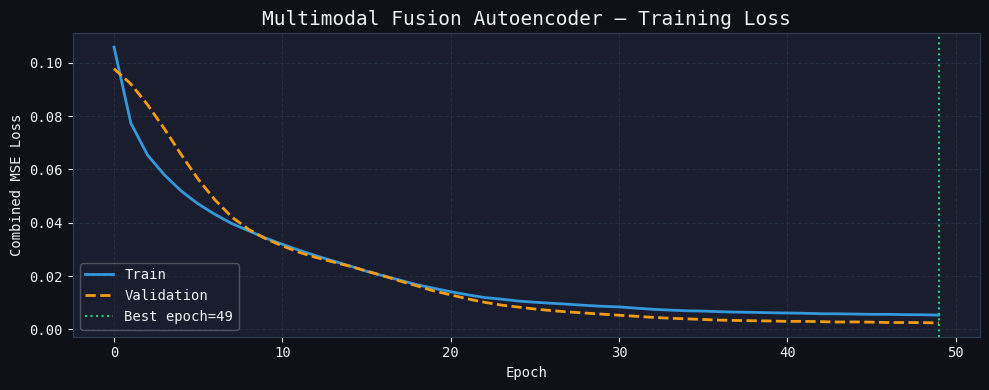

  Saved → outputs/01_ae_training_loss.png


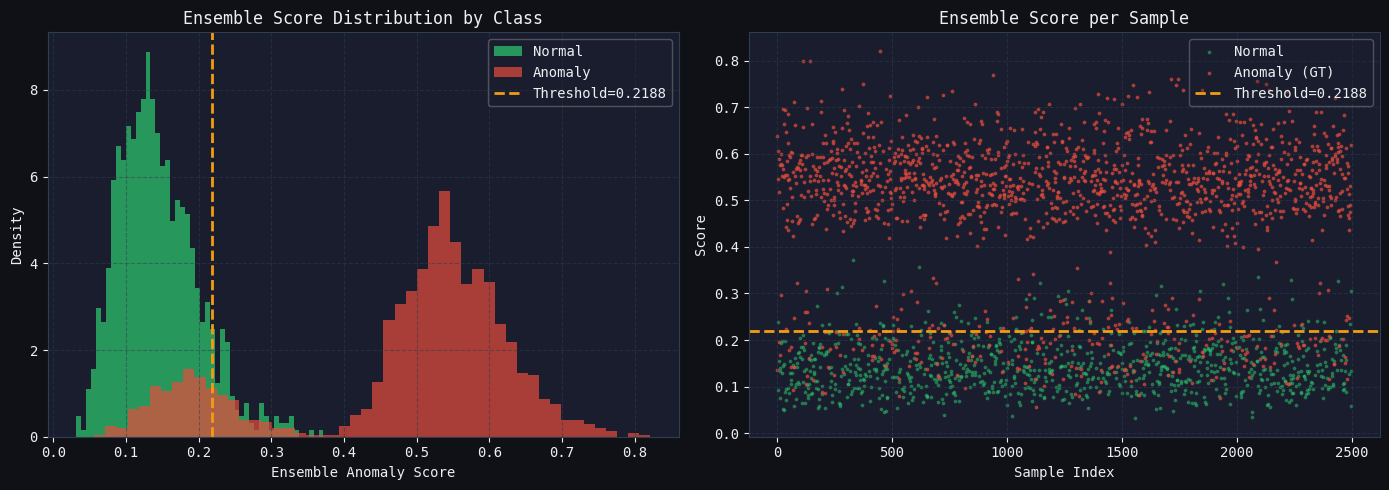

  Saved → outputs/02_ensemble_scores.png


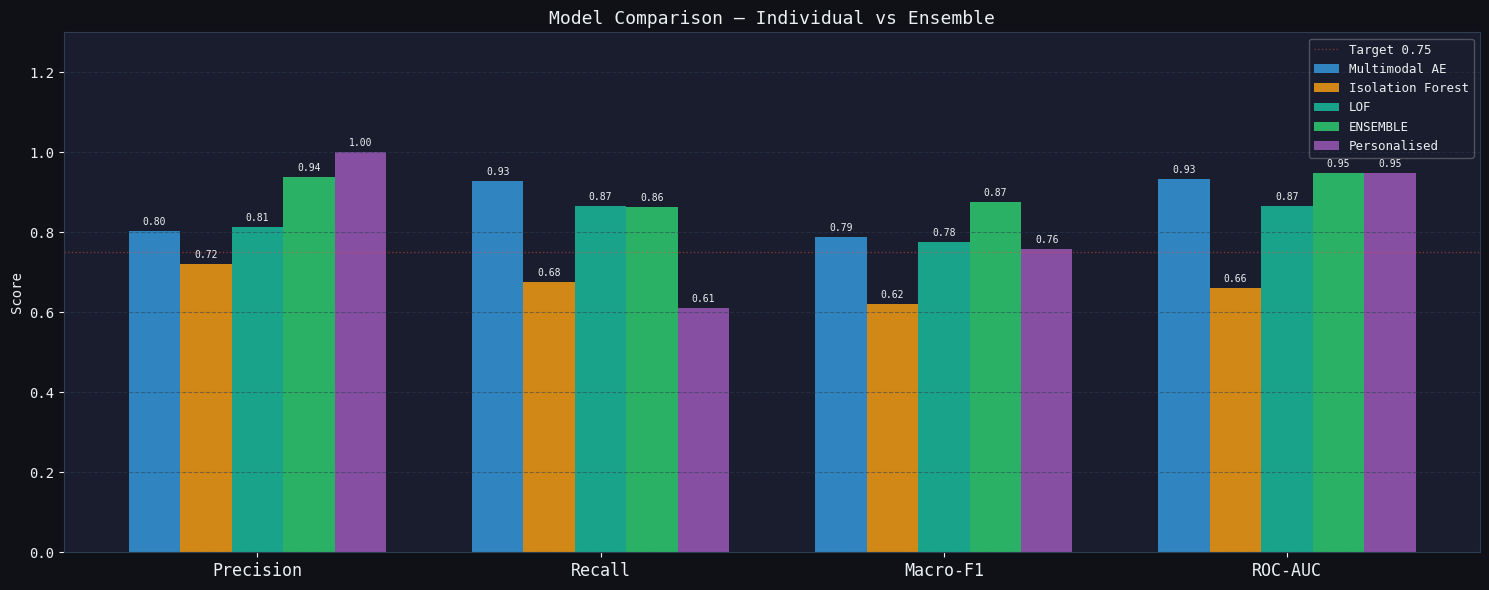

  Saved → outputs/03_model_comparison.png


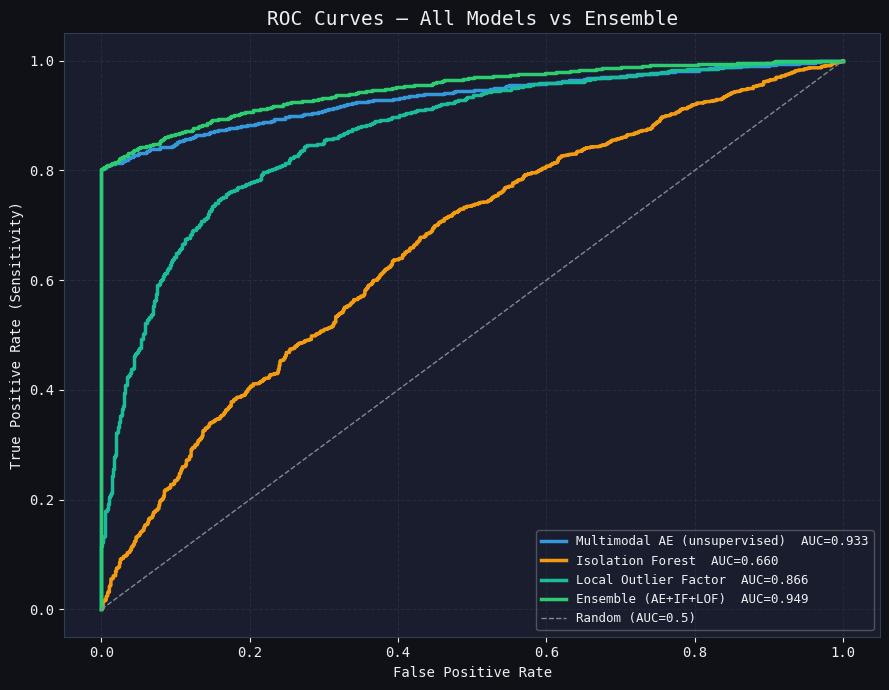

  Saved → outputs/04_roc_curves.png


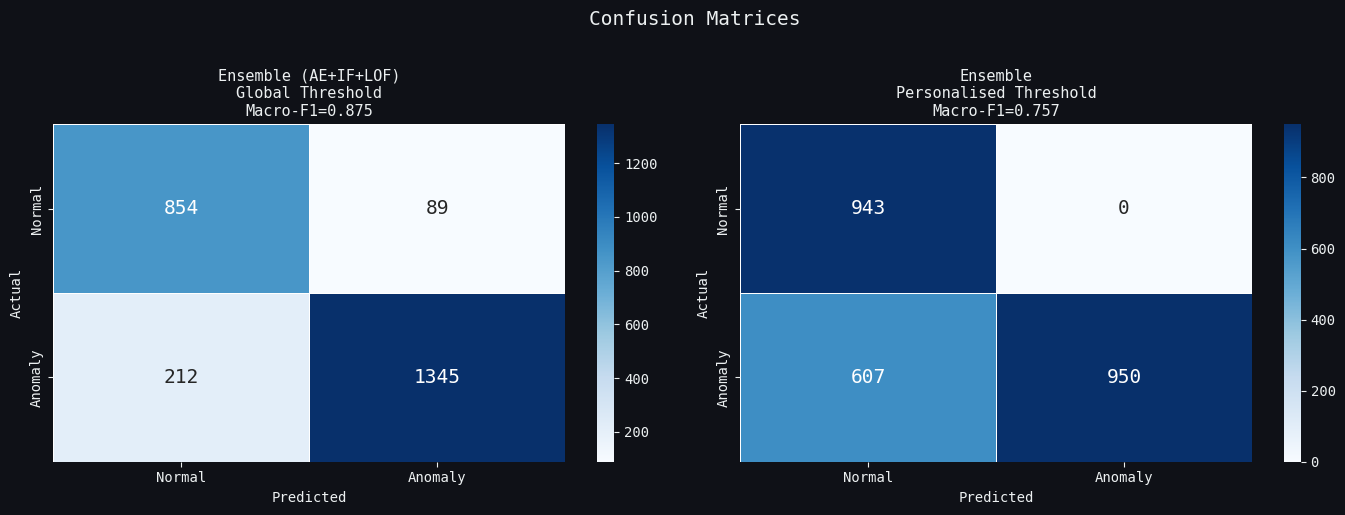

  Saved → outputs/05_confusion_matrices.png


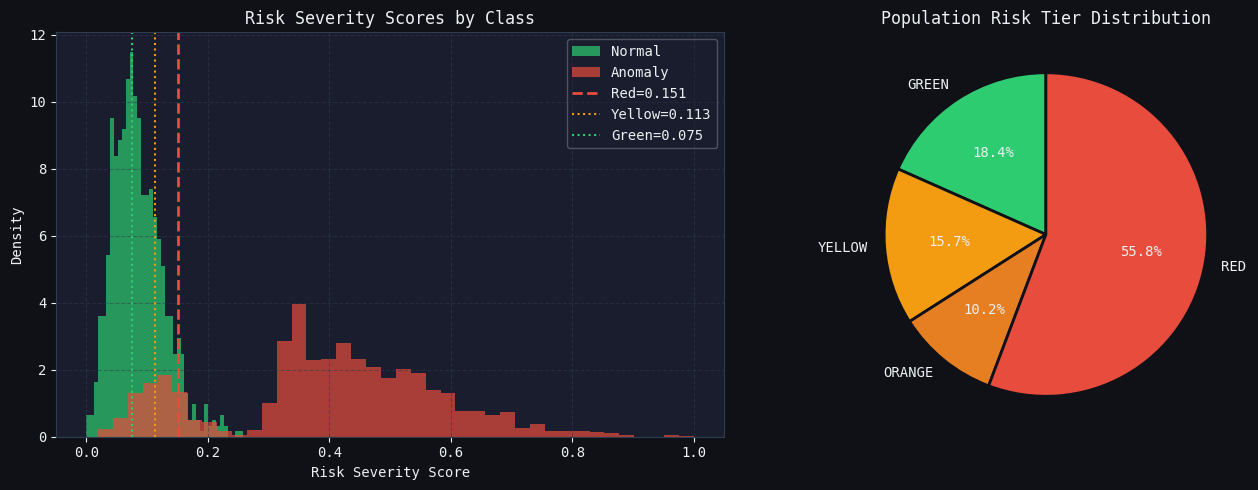

  Saved → outputs/06_risk_stratification.png


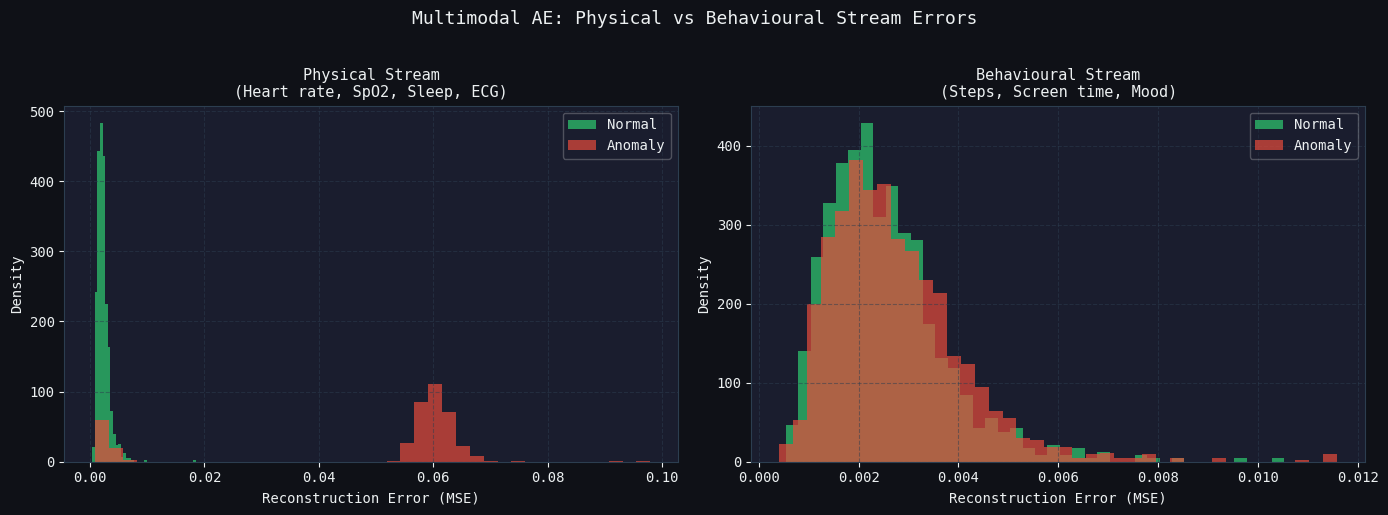

  Saved → outputs/07_stream_errors.png

✅ All visualisations saved to outputs/


In [13]:

C = dict(
    normal='#2ecc71', anomaly='#e74c3c', bg='#0f1117',
    card='#1a1d2e',   text='#ecf0f1',   blue='#3498db',
    gold='#f39c12',   purple='#9b59b6', teal='#1abc9c',
    orange='#e67e22',
)

def _style():
    plt.rcParams.update({
        'figure.facecolor': C['bg'],  'axes.facecolor': C['card'],
        'axes.edgecolor':  '#2c3e50', 'axes.labelcolor': C['text'],
        'xtick.color': C['text'],     'ytick.color': C['text'],
        'text.color':  C['text'],     'grid.color':  '#2c3e50',
        'grid.linestyle': '--',       'grid.alpha':   0.5,
        'font.family': 'monospace',
    })

def _save(fig, name):
    path = f'{OUTDIR}/{name}'
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.show(); plt.close(fig)
    print(f'  Saved → {path}')

#AE Training Loss
_style()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ae_history.history['loss'],
        color=C['blue'], lw=2, label='Train')
ax.plot(ae_history.history['val_loss'],
        color=C['gold'], lw=2, linestyle='--', label='Validation')
best_ep = np.argmin(ae_history.history['val_loss'])
ax.axvline(best_ep, color=C['normal'], lw=1.5, linestyle=':',
           label=f'Best epoch={best_ep}')
ax.set_title('Multimodal Fusion Autoencoder — Training Loss',
             fontsize=14)
ax.set_xlabel('Epoch'); ax.set_ylabel('Combined MSE Loss')
ax.legend(framealpha=0.3); ax.grid(True)
fig.tight_layout(); _save(fig, '01_ae_training_loss.png')

#Ensemble Score Distribution
_style()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.hist(ens_scores_te[y_te==0], bins=50, color=C['normal'],
        alpha=0.7, label='Normal', density=True)
ax.hist(ens_scores_te[y_te==1], bins=50, color=C['anomaly'],
        alpha=0.7, label='Anomaly', density=True)
ax.axvline(ens_threshold, color=C['gold'], lw=2, linestyle='--',
           label=f'Threshold={ens_threshold:.4f}')
ax.set_title('Ensemble Score Distribution by Class')
ax.set_xlabel('Ensemble Anomaly Score')
ax.set_ylabel('Density')
ax.legend(framealpha=0.3); ax.grid(True)

ax = axes[1]
t = np.arange(len(ens_scores_te))
ax.scatter(t[y_te==0], ens_scores_te[y_te==0],
           s=3, color=C['normal'], alpha=0.4, label='Normal')
ax.scatter(t[y_te==1], ens_scores_te[y_te==1],
           s=3, color=C['anomaly'], alpha=0.6, label='Anomaly (GT)')
ax.axhline(ens_threshold, color=C['gold'], lw=2, linestyle='--',
           label=f'Threshold={ens_threshold:.4f}')
ax.set_title('Ensemble Score per Sample')
ax.set_xlabel('Sample Index'); ax.set_ylabel('Score')
ax.legend(framealpha=0.3); ax.grid(True)
fig.tight_layout(); _save(fig, '02_ensemble_scores.png')

#Model Comparison
_style()
metrics    = ['Precision', 'Recall', 'Macro-F1', 'ROC-AUC']
all_models = [
    ('Multimodal AE',    pred_ae,       ae_norm_te,   C['blue']),
    ('Isolation Forest', pred_if,       if_norm_te,   C['gold']),
    ('LOF',              pred_lof,      lof_norm_te,  C['teal']),
    ('ENSEMBLE',         pred_ensemble, ens_scores_te,C['normal']),
    ('Personalised',     pred_personal, ens_scores_te,C['purple']),
]

def get_vals(y, pred, score):
    try:    auc = roc_auc_score(y, score)
    except: auc = 0.0
    return [precision_score(y, pred, zero_division=0),
            recall_score(y,    pred, zero_division=0),
            f1_score(y,        pred, average='macro',
                     zero_division=0), auc]

x = np.arange(len(metrics)); w = 0.15
offsets = np.linspace(-2*w, 2*w, 5)
fig, ax = plt.subplots(figsize=(15, 6))
for (name, pred, score, col), offset in zip(all_models, offsets):
    vals = get_vals(y_te, pred, score)
    bars = ax.bar(x+offset, vals, w,
                  label=name, color=col, alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2,
                h+0.01, f'{h:.2f}',
                ha='center', va='bottom', fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.3)
ax.axhline(0.75, color=C['anomaly'], lw=1,
           linestyle=':', alpha=0.5, label='Target 0.75')
ax.set_title('Model Comparison — Individual vs Ensemble',
             fontsize=13)
ax.set_ylabel('Score')
ax.legend(framealpha=0.3, fontsize=9)
ax.grid(True, axis='y')
fig.tight_layout(); _save(fig, '03_model_comparison.png')

#ROC Curves
_style()
fig, ax = plt.subplots(figsize=(9, 7))
for scores, label, col in [
    (ae_norm_te,   'Multimodal AE (unsupervised)', C['blue']),
    (if_norm_te,   'Isolation Forest',             C['gold']),
    (lof_norm_te,  'Local Outlier Factor',          C['teal']),
    (ens_scores_te,'Ensemble (AE+IF+LOF)',          C['normal']),
]:
    try:
        fpr, tpr, _ = roc_curve(y_te, scores)
        auc = roc_auc_score(y_te, scores)
        ax.plot(fpr, tpr, lw=2.5, color=col,
                label=f'{label}  AUC={auc:.3f}')
    except Exception:
        pass
ax.plot([0,1],[0,1], color='#7f8c8d', lw=1,
        linestyle='--', label='Random (AUC=0.5)')
ax.set_title('ROC Curves — All Models vs Ensemble', fontsize=14)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.legend(framealpha=0.3, fontsize=9, loc='lower right')
ax.grid(True)
fig.tight_layout(); _save(fig, '04_roc_curves.png')

#Confusion Matrices
_style()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, preds, title in [
    (axes[0], pred_ensemble,
     'Ensemble (AE+IF+LOF)\nGlobal Threshold'),
    (axes[1], pred_personal,
     'Ensemble\nPersonalised Threshold'),
]:
    cm  = confusion_matrix(y_te, preds)
    mf1 = f1_score(y_te, preds,
                   average='macro', zero_division=0)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal','Anomaly'],
                yticklabels=['Normal','Anomaly'],
                linewidths=0.5, annot_kws={'size':14})
    ax.set_title(f'{title}\nMacro-F1={mf1:.3f}', fontsize=11)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
fig.suptitle('Confusion Matrices', fontsize=14, y=1.02)
fig.tight_layout(); _save(fig, '05_confusion_matrices.png')

#Risk Severity Distribution
_style()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(risk_severity_te[y_te==0], bins=40,
             color=C['normal'], alpha=0.7,
             label='Normal', density=True)
axes[0].hist(risk_severity_te[y_te==1], bins=40,
             color=C['anomaly'], alpha=0.7,
             label='Anomaly', density=True)
axes[0].axvline(red_boundary,    color=C['anomaly'],
                lw=2, linestyle='--',
                label=f'Red={red_boundary:.3f}')
axes[0].axvline(yellow_boundary, color=C['gold'],
                lw=1.5, linestyle=':',
                label=f'Yellow={yellow_boundary:.3f}')
axes[0].axvline(green_boundary,  color=C['normal'],
                lw=1.5, linestyle=':',
                label=f'Green={green_boundary:.3f}')
axes[0].set_title('Risk Severity Scores by Class')
axes[0].set_xlabel('Risk Severity Score')
axes[0].set_ylabel('Density')
axes[0].legend(framealpha=0.3); axes[0].grid(True)

tier_counts = pd.Series(tier_labels_te).value_counts().sort_index()
tier_names  = [TIERS[i][0] for i in tier_counts.index]
tier_colors = [C['normal'], C['gold'], C['orange'], C['anomaly']]
axes[1].pie(tier_counts.values,
            labels=tier_names,
            colors=tier_colors[:len(tier_counts)],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': C['bg'], 'linewidth': 2})
axes[1].set_title('Population Risk Tier Distribution')
fig.tight_layout(); _save(fig, '06_risk_stratification.png')

#Physical vs Behavioural Stream Errors
_style()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, errs, title in [
    (axes[0], ae_phys_err_te,
     'Physical Stream\n(Heart rate, SpO2, Sleep, ECG)'),
    (axes[1], ae_beh_err_te,
     'Behavioural Stream\n(Steps, Screen time, Mood)'),
]:
    ax.hist(errs[y_te==0], bins=40, color=C['normal'],
            alpha=0.7, label='Normal', density=True)
    ax.hist(errs[y_te==1], bins=40, color=C['anomaly'],
            alpha=0.7, label='Anomaly', density=True)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Reconstruction Error (MSE)')
    ax.set_ylabel('Density')
    ax.legend(framealpha=0.3); ax.grid(True)
fig.suptitle('Multimodal AE: Physical vs Behavioural Stream Errors',
             fontsize=13, y=1.02)
fig.tight_layout(); _save(fig, '07_stream_errors.png')

print('\n✅ All visualisations saved to outputs/')